# Thesis visualisations — CLEAN (pool-aware) version

Corrected for the data-contamination issue: loads `all_results_CLEAN.csv` (duplicate RQ1 run removed, `pool` column added) and **averages within each LODO pool only**, so the four datasets that appear in both RQ1 and an RQ2 domain (Pijls, Pinos-Cisneros, Tumkaya, Rinne) no longer mix experiments.

Figures are written to `results/figures_clean/`. The final cell exports `thesis_stats_clean.csv` with every recomputed statistic for updating the thesis.

# Thesis Visualisations — Regeneration Notebook

Loads `results/all_results.csv` and regenerates every figure and summary table in the thesis.

**C2a/C2b relabelling is applied automatically** (SciBERT+SVM → C2a isolation control; SciBERT+LR → C2b).

Run all cells top-to-bottom. Figures are saved to `figures/` in the same directory as the CSV.


In [17]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from scipy.stats import wilcoxon, friedmanchisquare
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
RESULTS_CSV = Path('results/all_results_CLEAN.csv')   # CLEAN: deduped + pool column (see post_review_analysis.ipynb)
FIG_DIR     = RESULTS_CSV.parent / 'figures_clean'
FIG_DIR.mkdir(exist_ok=True)

# ── Dataset pools ──────────────────────────────────────────────────────────────
RQ1 = [
    'Greca_2023', 'Pijls_2018', 'Tumkaya_2018', 'Rinne_2021',
    'Pinos-Cisneros_2023', 'Abgaz_2023', 'Erer_2015',
    'Demirkaya_2015', 'Leenaars_2020', 'Eggmann_2023',
]
RQ2_A = ['Pijls_2018', 'Cozim-Melges_2024', 'Pinos-Cisneros_2023',
          'van_der_Valk_2021', 'Meijboom_2021', 'Tektonidou_2019']
RQ2_B = ['Tumkaya_2018', 'Rinne_2021', 'Donners_2021',
          'Smid_2019', 'Boersma-van_Dam_2024', 'Oud_2018']

# ── C2a / C2b label swap ───────────────────────────────────────────────────────
# Old C2b (SciBERT+SVM) becomes the new C2a (isolation control)
# Old C2a (SciBERT+LR)  becomes the new C2b
LABEL_SWAP = {
    'C2a_SciBERT_LR':  'C2b_SciBERT_LR',
    'C2b_SciBERT_SVM': 'C2a_SciBERT_SVM',
}

# ── Display names & colours (ordered C1 → C4) ─────────────────────────────────
CONDITION_ORDER = [
    'C1_TFIDF_SVM',
    'C2a_SciBERT_SVM',   # isolation control (was C2b)
    'C2b_SciBERT_LR',    # SciBERT+LR        (was C2a)
    'C3_GAT_only',
    'C4_GNN_NLP_Fusion',
]
DISPLAY = {
    'C1_TFIDF_SVM':       'C1 (TF-IDF SVM)',
    'C2a_SciBERT_SVM':    'C2a (SciBERT SVM)',
    'C2b_SciBERT_LR':     'C2b (SciBERT LR)',
    'C3_GAT_only':        'C3 (GAT-only)',
    'C4_GNN_NLP_Fusion':  'C4 (GNN+NLP)',
}
COLOURS = {
    'C1_TFIDF_SVM':       '#4C72B0',
    'C2a_SciBERT_SVM':    '#55A868',
    'C2b_SciBERT_LR':     '#8172B2',
    'C3_GAT_only':        '#C44E52',
    'C4_GNN_NLP_Fusion':  '#CCB974',
}

print('Config loaded.')


Config loaded.


In [18]:
raw = pd.read_csv(RESULTS_CSV)
# all_results_CLEAN.csv already has a `pool` column, the duplicate RQ1 run removed,
# and the C2a/C2b relabelling applied. LABEL_SWAP is a harmless no-op here.
raw['model'] = raw['model'].replace(LABEL_SWAP)

# CRITICAL: average within each pool only — never collapse a dataset across pools.
# (Pijls/Pinos/Tumkaya/Rinne appear in both RQ1 and an RQ2 pool with different values.)
means = (raw.groupby(['pool', 'dataset', 'model'])['nl']
           .mean().reset_index().rename(columns={'nl': 'mean_nl'}))

def rq_subset(pool_name, datasets):
    return means[(means['pool'] == pool_name) & (means['dataset'].isin(datasets))].copy()

rq1_df  = rq_subset('RQ1', RQ1)
rq2a_df = rq_subset('RQ2_A_osteoarthritis', RQ2_A)
rq2b_df = rq_subset('RQ2_B_ptsd', RQ2_B)

# sanity: exactly one row per dataset x condition in each pool
assert (rq1_df.groupby('dataset').size() == len(CONDITION_ORDER)).all(), 'RQ1 not one row per dataset x condition'
print(f'Loaded {len(raw)} clean rows; pools: {sorted(raw["pool"].unique())}')
print(f'RQ1 datasets: {rq1_df.dataset.nunique()} | conditions: {sorted(means.model.unique())}')
print('Pool mean NL (RQ1):')
print(rq1_df.groupby("model")["mean_nl"].mean().reindex(CONDITION_ORDER).round(3).to_string())

Loaded 550 clean rows; pools: ['RQ1', 'RQ2_A_osteoarthritis', 'RQ2_B_ptsd']
RQ1 datasets: 10 | conditions: ['C1_TFIDF_SVM', 'C2a_SciBERT_SVM', 'C2b_SciBERT_LR', 'C3_GAT_only', 'C4_GNN_NLP_Fusion']
Pool mean NL (RQ1):
model
C1_TFIDF_SVM         0.338
C2a_SciBERT_SVM      0.293
C2b_SciBERT_LR       0.291
C3_GAT_only          0.369
C4_GNN_NLP_Fusion    0.282


## Figure 5 — NL Distribution per Condition (RQ1 violin + strip)

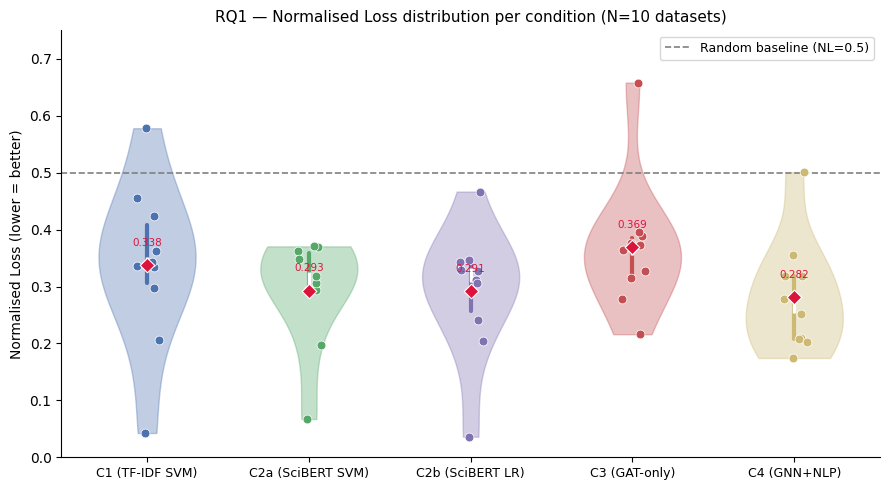

Saved fig5_violin_rq1.png


In [19]:
fig, ax = plt.subplots(figsize=(9, 5))

for i, cond in enumerate(CONDITION_ORDER):
    data = rq1_df[rq1_df.model == cond]['mean_nl'].values
    col  = COLOURS[cond]

    # violin
    vp = ax.violinplot(data, positions=[i], widths=0.6,
                       showmedians=False, showextrema=False)
    for pc in vp['bodies']:
        pc.set_facecolor(col); pc.set_alpha(0.35); pc.set_edgecolor(col)

    # IQR bar + median
    q1, med, q3 = np.percentile(data, [25, 50, 75])
    ax.plot([i, i], [q1, q3], color=col, lw=3, solid_capstyle='round')
    ax.plot(i, med, 'w|', markersize=10, markeredgewidth=2.5)

    # jittered dots
    jitter = np.random.default_rng(42).uniform(-0.08, 0.08, len(data))
    ax.scatter([i + j for j in jitter], data, color=col,
               s=40, zorder=3, edgecolors='white', linewidths=0.5)

    # pool mean diamond
    ax.scatter(i, data.mean(), marker='D', color='crimson',
               s=55, zorder=4, edgecolors='white', linewidths=0.8)
    ax.text(i, data.mean() + 0.03, f'{data.mean():.3f}',
            ha='center', va='bottom', fontsize=7.5, color='crimson')

ax.axhline(0.5, ls='--', color='grey', lw=1.2, label='Random baseline (NL=0.5)')
ax.set_xticks(range(len(CONDITION_ORDER)))
ax.set_xticklabels([DISPLAY[c] for c in CONDITION_ORDER], fontsize=9)
ax.set_ylabel('Normalised Loss (lower = better)', fontsize=10)
ax.set_title('RQ1 — Normalised Loss distribution per condition (N=10 datasets)', fontsize=11)
ax.legend(fontsize=9); ax.set_ylim(0, 0.75)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig5_violin_rq1.png', dpi=200, bbox_inches='tight')
plt.show(); print('Saved fig5_violin_rq1.png')


## Figure 6 — Per-Dataset NL Heatmap with Ranks (RQ1)

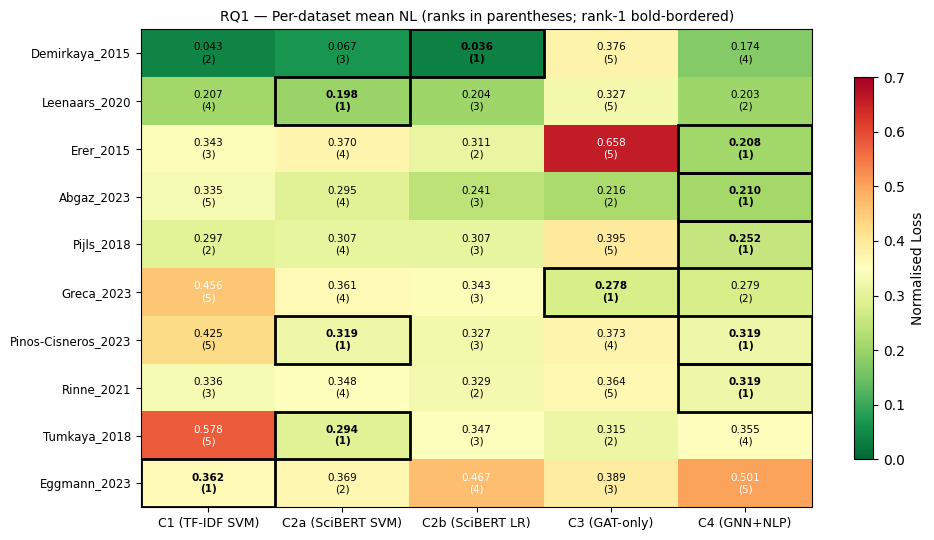

Saved fig6_heatmap_rq1.png


In [20]:
pivot = (rq1_df.pivot(index='dataset', columns='model', values='mean_nl')
               [CONDITION_ORDER])
# sort rows by C4 performance
pivot = pivot.sort_values('C4_GNN_NLP_Fusion')

# rank within each row (1 = best)
ranks = pivot.rank(axis=1, method='min').astype(int)

fig, ax = plt.subplots(figsize=(10, 5.5))
im = ax.imshow(pivot.values, cmap='RdYlGn_r', vmin=0.0, vmax=0.7, aspect='auto')

ax.set_xticks(range(len(CONDITION_ORDER)))
ax.set_xticklabels([DISPLAY[c] for c in CONDITION_ORDER], fontsize=9)
ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(pivot.index, fontsize=8.5)

for r in range(len(pivot)):
    for c in range(len(CONDITION_ORDER)):
        cond = CONDITION_ORDER[c]
        val  = pivot.iloc[r, c]
        rank = ranks.iloc[r, c]
        cell_txt = f'{val:.3f}\n({rank})'
        weight = 'bold' if rank == 1 else 'normal'
        border = rank == 1
        ax.text(c, r, cell_txt, ha='center', va='center',
                fontsize=7.5, fontweight=weight,
                color='white' if val > 0.45 else 'black')
        if border:
            rect = plt.Rectangle((c-0.5, r-0.5), 1, 1,
                                  fill=False, edgecolor='black', lw=2)
            ax.add_patch(rect)

plt.colorbar(im, ax=ax, label='Normalised Loss', shrink=0.8)
ax.set_title('RQ1 — Per-dataset mean NL (ranks in parentheses; rank-1 bold-bordered)',
             fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig6_heatmap_rq1.png', dpi=200, bbox_inches='tight')
plt.show(); print('Saved fig6_heatmap_rq1.png')


## Figure 7 — Per-Dataset ΔNL Improvement Over C1 Baseline

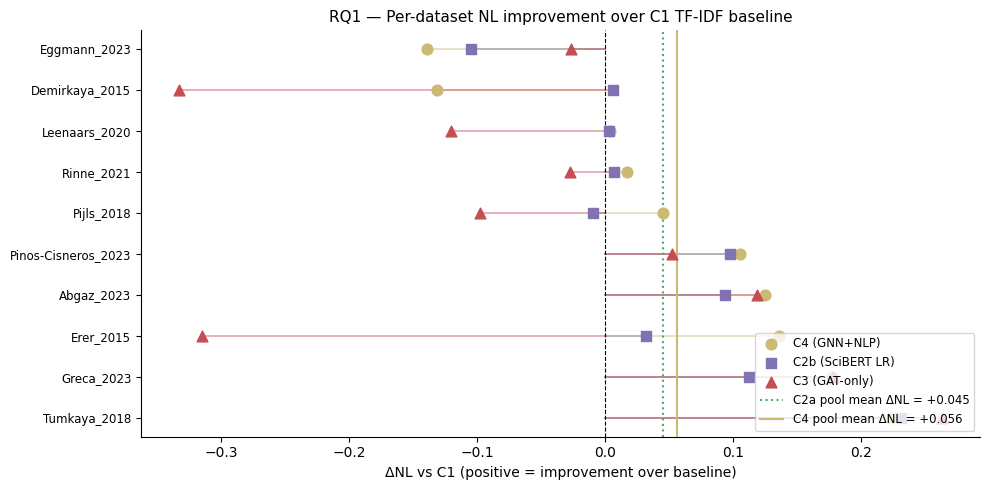

Saved fig7_delta_nl_lollipop.png


In [21]:
c1_means = (rq1_df[rq1_df.model == 'C1_TFIDF_SVM']
            .set_index('dataset')['mean_nl'])

delta_conds = ['C4_GNN_NLP_Fusion', 'C2b_SciBERT_LR', 'C3_GAT_only']
markers     = {'C4_GNN_NLP_Fusion': 'o', 'C2b_SciBERT_LR': 's', 'C3_GAT_only': '^'}

# sort datasets by C4 delta
c4_delta = (rq1_df[rq1_df.model == 'C4_GNN_NLP_Fusion']
            .set_index('dataset')['mean_nl'].rsub(c1_means))
dataset_order = c4_delta.sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(10, 5))

for cond in delta_conds:
    cond_means = (rq1_df[rq1_df.model == cond]
                  .set_index('dataset')['mean_nl'])
    delta = c1_means - cond_means          # positive = improvement

    xs = [delta[ds] for ds in dataset_order]
    ys = range(len(dataset_order))
    for y, x in zip(ys, xs):
        ax.plot([0, x], [y, y], color=COLOURS[cond], alpha=0.5, lw=1.2)
    ax.scatter(xs, ys, color=COLOURS[cond], marker=markers[cond],
               s=60, zorder=3, label=DISPLAY[cond])

# C2a pool mean reference line
c2a_pool_delta = (c1_means - rq1_df[rq1_df.model == 'C2a_SciBERT_SVM']
                  .set_index('dataset')['mean_nl']).mean()
ax.axvline(c2a_pool_delta, ls=':', color=COLOURS['C2a_SciBERT_SVM'],
           lw=1.5, label=f'C2a pool mean ΔNL = {c2a_pool_delta:+.3f}')

c4_pool_delta = (c1_means - rq1_df[rq1_df.model == 'C4_GNN_NLP_Fusion']
                 .set_index('dataset')['mean_nl']).mean()
ax.axvline(c4_pool_delta, ls='-', color=COLOURS['C4_GNN_NLP_Fusion'],
           lw=1.5, label=f'C4 pool mean ΔNL = {c4_pool_delta:+.3f}')

ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_yticks(range(len(dataset_order)))
ax.set_yticklabels(dataset_order, fontsize=8.5)
ax.set_xlabel('ΔNL vs C1 (positive = improvement over baseline)', fontsize=10)
ax.set_title('RQ1 — Per-dataset NL improvement over C1 TF-IDF baseline', fontsize=11)
ax.legend(fontsize=8.5, loc='lower right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig7_delta_nl_lollipop.png', dpi=200, bbox_inches='tight')
plt.show(); print('Saved fig7_delta_nl_lollipop.png')


## Figure 8 — C3 GAT-Only Per-Dataset Performance (bar + seed spread)

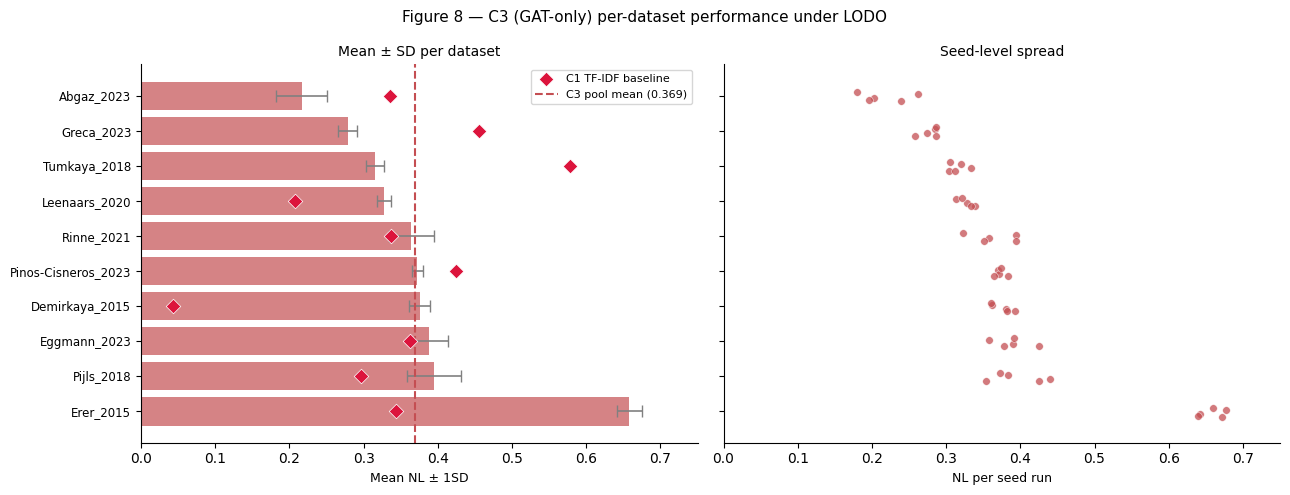

Saved fig8_c3_per_dataset.png


In [22]:
c3_raw  = raw[(raw.model == 'C3_GAT_only') & (raw['pool'] == 'RQ1') & (raw.dataset.isin(RQ1))].copy()
c3_mean = c3_raw.groupby('dataset')['nl'].mean()
c1_ref  = rq1_df[rq1_df.model == 'C1_TFIDF_SVM'].set_index('dataset')['mean_nl']
order   = c3_mean.sort_values(ascending=False).index.tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

ys = range(len(order))

# Left: mean ± 1SD bars
means_c3 = [c3_mean[ds] for ds in order]
sds_c3   = [c3_raw[c3_raw.dataset == ds]['nl'].std() for ds in order]
ax1.barh(ys, means_c3, xerr=sds_c3, color=COLOURS['C3_GAT_only'],
         alpha=0.7, capsize=4, error_kw={'ecolor': 'grey', 'lw': 1.2})
ax1.scatter([c1_ref[ds] for ds in order], ys,
            marker='D', color='crimson', s=55, zorder=4,
            label='C1 TF-IDF baseline', edgecolors='white', linewidths=0.5)
ax1.axvline(c3_mean.mean(), ls='--', color=COLOURS['C3_GAT_only'],
            lw=1.5, label=f'C3 pool mean ({c3_mean.mean():.3f})')
ax1.set_xlabel('Mean NL ± 1SD', fontsize=9)
ax1.set_title('Mean ± SD per dataset', fontsize=10)
ax1.legend(fontsize=8); ax1.spines[['top','right']].set_visible(False)

# Right: individual seed dots
for i, ds in enumerate(order):
    seed_vals = c3_raw[c3_raw.dataset == ds]['nl'].values
    jitter = np.random.default_rng(0).uniform(-0.15, 0.15, len(seed_vals))
    ax2.scatter(seed_vals, [i + j for j in jitter],
                color=COLOURS['C3_GAT_only'], s=30, alpha=0.75,
                edgecolors='white', linewidths=0.4)
ax2.set_xlabel('NL per seed run', fontsize=9)
ax2.set_title('Seed-level spread', fontsize=10)
ax2.spines[['top','right']].set_visible(False)

for ax in (ax1, ax2):
    ax.set_yticks(ys); ax.set_yticklabels(order, fontsize=8.5)
    ax.set_xlim(0, 0.75)

fig.suptitle('Figure 8 — C3 (GAT-only) per-dataset performance under LODO', fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig8_c3_per_dataset.png', dpi=200, bbox_inches='tight')
plt.show(); print('Saved fig8_c3_per_dataset.png')


## Figure 9 — C4 GNN+NLP Per-Dataset Performance (bar + seed spread)

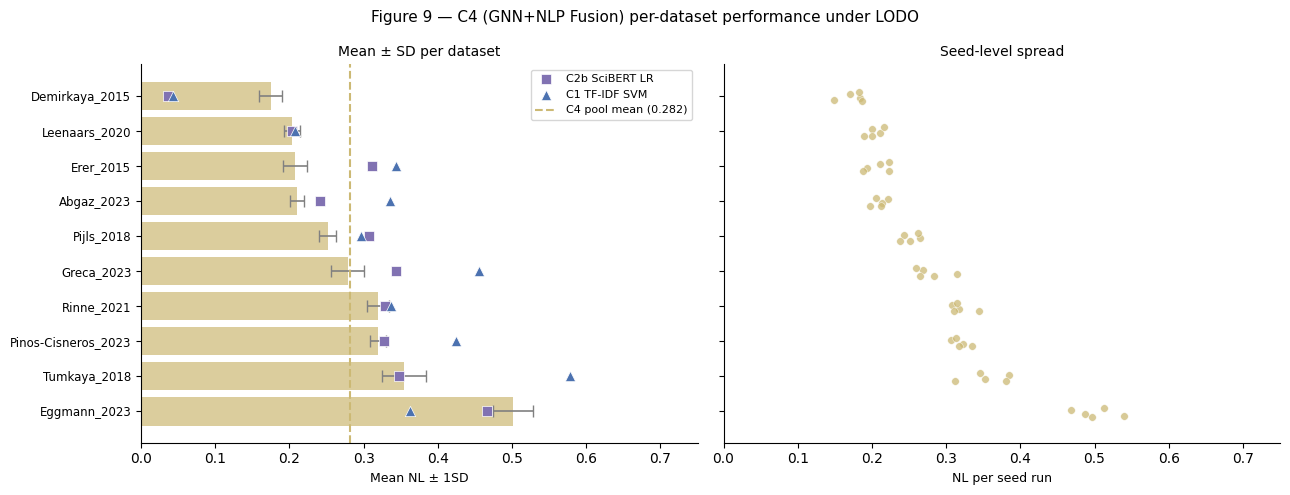

Saved fig9_c4_per_dataset.png


In [23]:
c4_raw  = raw[(raw.model == 'C4_GNN_NLP_Fusion') & (raw['pool'] == 'RQ1') & (raw.dataset.isin(RQ1))].copy()
c4_mean = c4_raw.groupby('dataset')['nl'].mean()
c2b_ref = rq1_df[rq1_df.model == 'C2b_SciBERT_LR'].set_index('dataset')['mean_nl']
order   = c4_mean.sort_values(ascending=False).index.tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
ys = range(len(order))

# Left: mean ± SD
means_c4 = [c4_mean[ds] for ds in order]
sds_c4   = [c4_raw[c4_raw.dataset == ds]['nl'].std() for ds in order]
ax1.barh(ys, means_c4, xerr=sds_c4, color=COLOURS['C4_GNN_NLP_Fusion'],
         alpha=0.7, capsize=4, error_kw={'ecolor': 'grey', 'lw': 1.2})
ax1.scatter([c2b_ref[ds] for ds in order], ys,
            marker='s', color=COLOURS['C2b_SciBERT_LR'], s=55, zorder=4,
            label='C2b SciBERT LR', edgecolors='white', linewidths=0.5)
ax1.scatter([c1_ref[ds] for ds in order], ys,
            marker='^', color=COLOURS['C1_TFIDF_SVM'], s=55, zorder=4,
            label='C1 TF-IDF SVM', edgecolors='white', linewidths=0.5)
ax1.axvline(c4_mean.mean(), ls='--', color=COLOURS['C4_GNN_NLP_Fusion'],
            lw=1.5, label=f'C4 pool mean ({c4_mean.mean():.3f})')
ax1.set_xlabel('Mean NL ± 1SD', fontsize=9)
ax1.set_title('Mean ± SD per dataset', fontsize=10)
ax1.legend(fontsize=8); ax1.spines[['top','right']].set_visible(False)

# Right: seed dots
for i, ds in enumerate(order):
    seed_vals = c4_raw[c4_raw.dataset == ds]['nl'].values
    jitter = np.random.default_rng(0).uniform(-0.15, 0.15, len(seed_vals))
    ax2.scatter(seed_vals, [i + j for j in jitter],
                color=COLOURS['C4_GNN_NLP_Fusion'], s=30, alpha=0.75,
                edgecolors='white', linewidths=0.4)
ax2.set_xlabel('NL per seed run', fontsize=9)
ax2.set_title('Seed-level spread', fontsize=10)
ax2.spines[['top','right']].set_visible(False)

for ax in (ax1, ax2):
    ax.set_yticks(ys); ax.set_yticklabels(order, fontsize=8.5)
    ax.set_xlim(0, 0.75)

fig.suptitle('Figure 9 — C4 (GNN+NLP Fusion) per-dataset performance under LODO', fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig9_c4_per_dataset.png', dpi=200, bbox_inches='tight')
plt.show(); print('Saved fig9_c4_per_dataset.png')


## Figure 10 — RQ2 Domain Mean NL (grouped bar)

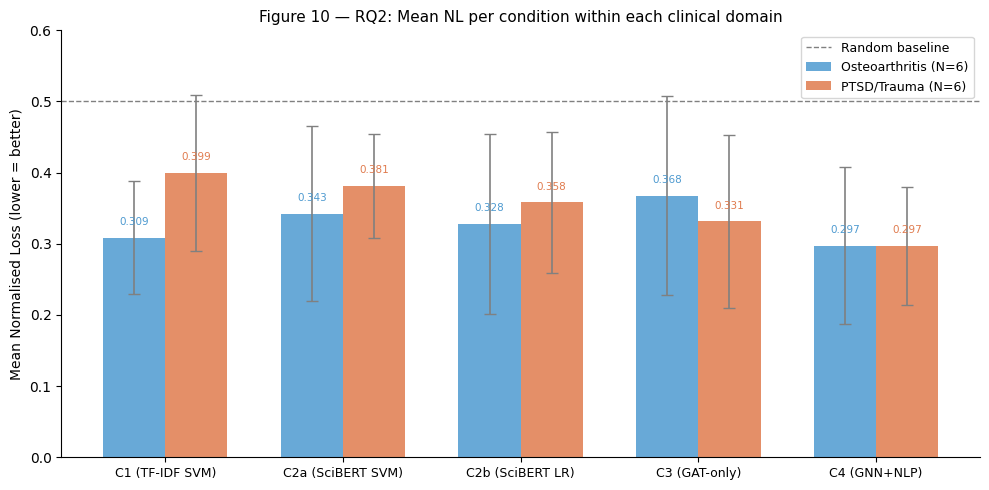

Saved fig10_rq2_grouped_bar.png


In [24]:
def domain_summary(pool_name, datasets):
    sub = means[(means['pool'] == pool_name) & (means['dataset'].isin(datasets))]
    return sub.groupby('model')['mean_nl'].agg(['mean','std']).reindex(CONDITION_ORDER)

dom_a = domain_summary('RQ2_A_osteoarthritis', RQ2_A)
dom_b = domain_summary('RQ2_B_ptsd', RQ2_B)

x = np.arange(len(CONDITION_ORDER))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_a = ax.bar(x - w/2, dom_a['mean'], w, yerr=dom_a['std'],
                capsize=4, color='#4e9ad0', label='Osteoarthritis (N=6)',
                error_kw={'ecolor': 'grey', 'lw': 1.2}, alpha=0.85)
bars_b = ax.bar(x + w/2, dom_b['mean'], w, yerr=dom_b['std'],
                capsize=4, color='#e07b4e', label='PTSD/Trauma (N=6)',
                error_kw={'ecolor': 'grey', 'lw': 1.2}, alpha=0.85)

# annotate means
for rect, val in zip(bars_a, dom_a['mean']):
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.015,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, color='#4e9ad0')
for rect, val in zip(bars_b, dom_b['mean']):
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.015,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, color='#e07b4e')

ax.axhline(0.5, ls='--', color='grey', lw=1, label='Random baseline')
ax.set_xticks(x)
ax.set_xticklabels([DISPLAY[c] for c in CONDITION_ORDER], fontsize=9)
ax.set_ylabel('Mean Normalised Loss (lower = better)', fontsize=10)
ax.set_title('Figure 10 — RQ2: Mean NL per condition within each clinical domain', fontsize=11)
ax.legend(fontsize=9); ax.set_ylim(0, 0.6)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig10_rq2_grouped_bar.png', dpi=200, bbox_inches='tight')
plt.show(); print('Saved fig10_rq2_grouped_bar.png')


## Figure 11 — Condition Ranking by Domain (slope chart)

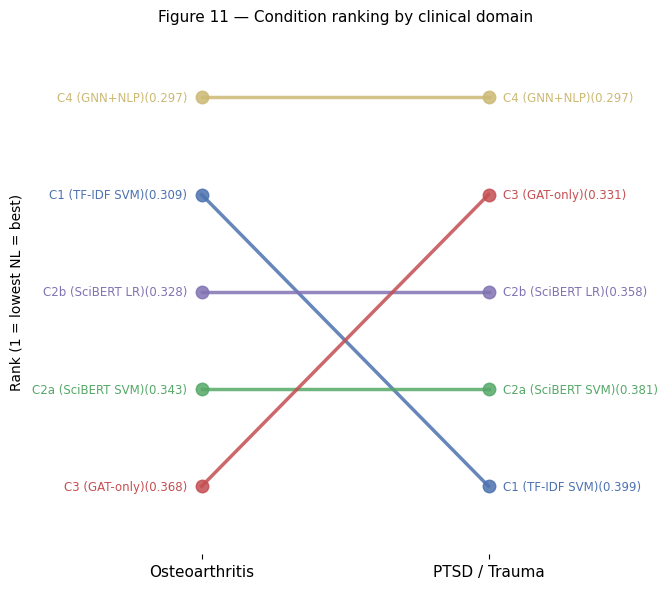

Saved fig11_slope_rq2.png


In [25]:
fig, ax = plt.subplots(figsize=(7, 6))

dom_a_mean = dom_a['mean']
dom_b_mean = dom_b['mean']

# rank within each domain (1 = best = lowest NL)
rank_a = dom_a_mean.rank().astype(int)
rank_b = dom_b_mean.rank().astype(int)

for cond in CONDITION_ORDER:
    ya = rank_a[cond]; yb = rank_b[cond]
    # plot connecting line
    ax.plot([0, 1], [ya, yb], color=COLOURS[cond], lw=2.5, alpha=0.85,
            marker='o', markersize=9)
    # left label
    ax.text(-0.05, ya, f'{DISPLAY[cond]}({dom_a_mean[cond]:.3f})',
            ha='right', va='center', fontsize=8.5, color=COLOURS[cond])
    # right label
    ax.text(1.05, yb, f'{DISPLAY[cond]}({dom_b_mean[cond]:.3f})',
            ha='left', va='center', fontsize=8.5, color=COLOURS[cond])

ax.set_xlim(-0.6, 1.6)
ax.set_ylim(0.3, len(CONDITION_ORDER) + 0.7)
ax.invert_yaxis()    # rank 1 at top
ax.set_xticks([0, 1])
ax.set_xticklabels(['Osteoarthritis', 'PTSD / Trauma'], fontsize=11)
ax.set_ylabel('Rank (1 = lowest NL = best)', fontsize=10)
ax.set_title('Figure 11 — Condition ranking by clinical domain', fontsize=11)
ax.spines[['top','right','left','bottom']].set_visible(False)
ax.set_yticks([]); ax.tick_params(left=False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig11_slope_rq2.png', dpi=200, bbox_inches='tight')
plt.show(); print('Saved fig11_slope_rq2.png')


## Summary Tables

In [26]:
# ── Table: RQ1 per-dataset mean NL ────────────────────────────────────────────
rq1_pivot = (rq1_df.pivot(index='dataset', columns='model', values='mean_nl')
                   [CONDITION_ORDER].round(3))
rq1_pivot.columns = [DISPLAY[c] for c in CONDITION_ORDER]
rq1_pivot.loc['MEAN'] = rq1_pivot.mean()
print('=== RQ1 Per-Dataset Mean NL (Table 2) ===')
print(rq1_pivot.to_string())
rq1_pivot.to_csv(RESULTS_CSV.parent / 'rq1_summary_table.csv')


=== RQ1 Per-Dataset Mean NL (Table 2) ===
                     C1 (TF-IDF SVM)  C2a (SciBERT SVM)  C2b (SciBERT LR)  C3 (GAT-only)  C4 (GNN+NLP)
dataset                                                                                               
Abgaz_2023                    0.3350             0.2950            0.2420         0.2160        0.2100
Demirkaya_2015                0.0430             0.0670            0.0360         0.3760        0.1740
Eggmann_2023                  0.3620             0.3690            0.4670         0.3890        0.5010
Erer_2015                     0.3430             0.3700            0.3120         0.6580        0.2080
Greca_2023                    0.4560             0.3620            0.3430         0.2780        0.2780
Leenaars_2020                 0.2070             0.1980            0.2040         0.3270        0.2030
Pijls_2018                    0.2970             0.3070            0.3070         0.3950        0.2520
Pinos-Cisneros_2023           0

In [27]:
# ── Table: RQ2 domain summary ─────────────────────────────────────────────────
rows = []
for domain, pool_name, datasets, label in [('Osteoarthritis', 'RQ2_A_osteoarthritis', RQ2_A, 'OA'),
                                            ('PTSD/Trauma', 'RQ2_B_ptsd', RQ2_B, 'PTSD')]:
    sub = means[(means['pool'] == pool_name) & (means['dataset'].isin(datasets))]
    for cond in CONDITION_ORDER:
        m = sub[sub.model == cond]['mean_nl']
        rows.append({'Domain': domain, 'Condition': DISPLAY[cond],
                     'Mean NL': round(m.mean(), 3), 'SD': round(m.std(), 3)})
rq2_table = pd.DataFrame(rows)
print('=== RQ2 Domain Summary (Table 3) ===')
print(rq2_table.to_string(index=False))
rq2_table.to_csv(RESULTS_CSV.parent / 'rq2_summary_table.csv', index=False)


=== RQ2 Domain Summary (Table 3) ===
        Domain         Condition  Mean NL    SD
Osteoarthritis   C1 (TF-IDF SVM)    0.309 0.079
Osteoarthritis C2a (SciBERT SVM)    0.343 0.123
Osteoarthritis  C2b (SciBERT LR)    0.328 0.126
Osteoarthritis     C3 (GAT-only)    0.368 0.140
Osteoarthritis      C4 (GNN+NLP)    0.297 0.110
   PTSD/Trauma   C1 (TF-IDF SVM)    0.399 0.110
   PTSD/Trauma C2a (SciBERT SVM)    0.381 0.073
   PTSD/Trauma  C2b (SciBERT LR)    0.358 0.099
   PTSD/Trauma     C3 (GAT-only)    0.331 0.121
   PTSD/Trauma      C4 (GNN+NLP)    0.297 0.083


## Statistical Tests (Friedman + Wilcoxon + Holm-Bonferroni)

In [28]:
from scipy.stats import friedmanchisquare, wilcoxon

print('=== RQ1 Friedman Test (N=10) ===')
groups = [rq1_df[rq1_df.model == c]['mean_nl'].values for c in CONDITION_ORDER]
stat, p = friedmanchisquare(*groups)
print(f'χ²({len(CONDITION_ORDER)-1}) = {stat:.3f}, p = {p:.3f}')

print()
print('=== Pairwise Wilcoxon vs C4 (Holm-Bonferroni corrected) ===')
c4_vals = rq1_df[rq1_df.model == 'C4_GNN_NLP_Fusion']['mean_nl'].values
comparisons = [c for c in CONDITION_ORDER if c != 'C4_GNN_NLP_Fusion']
raw_ps = []
for cond in comparisons:
    cond_vals = rq1_df[rq1_df.model == cond]['mean_nl'].values
    w, p_raw = wilcoxon(c4_vals, cond_vals)
    r = 1 - (4*w) / (len(c4_vals)*(len(c4_vals)+1))
    raw_ps.append((cond, w, p_raw, r))

# Holm-Bonferroni correction — build adjusted list first
raw_ps_sorted = sorted(raw_ps, key=lambda x: x[2])
n = len(raw_ps_sorted)
holm_ps = []
for i, (cond, w, p_raw, r) in enumerate(raw_ps_sorted):
    p_adj = min(p_raw * (n - i), 1.0)
    holm_ps.append((cond, w, p_raw, p_adj, r))

# Then enforce step-down monotonicity
for i in range(1, len(holm_ps)):
    cond, w, p_raw, p_adj, r = holm_ps[i]
    p_adj = max(p_adj, holm_ps[i-1][3])
    holm_ps[i] = (cond, w, p_raw, p_adj, r)

print(f'{"Comparison":<28} {"W":>6} {"p (raw)":>9} {"p (adj)":>9} {"r":>7}  Direction')
for cond, w, p_raw, p_adj, r in holm_ps:
    direction = f'C4 better (ΔNL = {c4_vals.mean() - rq1_df[rq1_df.model==cond]["mean_nl"].mean():+.3f})'
    print(f'C4 vs {DISPLAY[cond]:<22} {w:>6.1f} {p_raw:>9.3f} {p_adj:>9.3f} {r:>7.3f}  {direction}')


=== RQ1 Friedman Test (N=10) ===
χ²(4) = 5.688, p = 0.224

=== Pairwise Wilcoxon vs C4 (Holm-Bonferroni corrected) ===
Comparison                        W   p (raw)   p (adj)       r  Direction
C4 vs C3 (GAT-only)            10.0     0.084     0.336   0.636  C4 better (ΔNL = -0.087)
C4 vs C1 (TF-IDF SVM)          14.0     0.193     0.580   0.491  C4 better (ΔNL = -0.056)
C4 vs C2b (SciBERT LR)         18.0     0.375     0.750   0.345  C4 better (ΔNL = -0.009)
C4 vs C2a (SciBERT SVM)        20.0     0.767     0.767   0.273  C4 better (ΔNL = -0.011)


## Consolidated clean statistics → `thesis_stats_clean.csv`

One tidy long-format file (`section, key, metric, value`) with every recomputed number: RQ1 per-dataset NL, condition summary, ablation decomposition, Friedman, Wilcoxon-vs-C4, RQ2 domain means + Friedman, and the C1-vs-C4 correlation.

In [29]:
# ============================================================
# Consolidated CLEAN statistics  ->  thesis_stats_clean.csv
# ============================================================
from scipy.stats import friedmanchisquare, wilcoxon, spearmanr
recs=[]
def add(section,key,metric,value): recs.append({'section':section,'key':key,'metric':metric,'value':value})

piv = rq1_df.pivot(index='dataset', columns='model', values='mean_nl')[CONDITION_ORDER]

# (1) RQ1 per-dataset NL
for ds,row in piv.iterrows():
    for c in CONDITION_ORDER: add('RQ1_per_dataset_NL', ds, DISPLAY[c], round(row[c],3))

# (2) RQ1 condition pool summary (+ rank-1 wins)
wins={}
for _,row in piv.iterrows(): wins[row.idxmin()]=wins.get(row.idxmin(),0)+1
for c in CONDITION_ORDER:
    add('RQ1_condition_summary', DISPLAY[c],'pool_mean',round(piv[c].mean(),3))
    add('RQ1_condition_summary', DISPLAY[c],'pool_sd',  round(piv[c].std(),3))
    add('RQ1_condition_summary', DISPLAY[c],'pool_median',round(piv[c].median(),3))
    add('RQ1_condition_summary', DISPLAY[c],'rank1_wins',wins.get(c,0))

# (3) RQ1 ablation decomposition (paired Wilcoxon)
def paired(a,b):
    av,bv=piv[a].values,piv[b].values; d=bv.mean()-av.mean()
    W,p=wilcoxon(av,bv); r=1-4*W/(len(av)*(len(av)+1)); return d,p,r
for name,a,b in [('C1->C2a feature (TFIDF->SciBERT)','C1_TFIDF_SVM','C2a_SciBERT_SVM'),
                 ('C2a->C2b classifier','C2a_SciBERT_SVM','C2b_SciBERT_LR'),
                 ('C2b->C4 graph fusion','C2b_SciBERT_LR','C4_GNN_NLP_Fusion'),
                 ('C1->C4 total','C1_TFIDF_SVM','C4_GNN_NLP_Fusion')]:
    d,p,r=paired(a,b)
    add('RQ1_ablation',name,'dNL',round(d,3)); add('RQ1_ablation',name,'p',round(p,3)); add('RQ1_ablation',name,'r',round(r,3))

# (4) RQ1 Friedman + Wilcoxon vs C4 (Holm)
chi,p=friedmanchisquare(*[piv[c].values for c in CONDITION_ORDER])
add('RQ1_friedman','omnibus','chi2',round(chi,3)); add('RQ1_friedman','omnibus','df',len(CONDITION_ORDER)-1); add('RQ1_friedman','omnibus','p',round(p,3))
c4v=piv['C4_GNN_NLP_Fusion'].values
raw_ps=[]
for c in [x for x in CONDITION_ORDER if x!='C4_GNN_NLP_Fusion']:
    W,pr=wilcoxon(c4v,piv[c].values); r=1-4*W/(len(c4v)*(len(c4v)+1)); raw_ps.append([c,W,pr,r])
order=sorted(range(len(raw_ps)),key=lambda i:raw_ps[i][2]); m=len(raw_ps); padj=[None]*m; prev=0
for rank,i in enumerate(order):
    pa=min(raw_ps[i][2]*(m-rank),1.0); pa=max(pa,prev); prev=pa; padj[i]=pa
for i,(c,W,pr,r) in enumerate(raw_ps):
    k='C4_vs_'+c.split('_')[0]
    add('RQ1_wilcoxon_vsC4',k,'W',round(W,1)); add('RQ1_wilcoxon_vsC4',k,'p_raw',round(pr,3))
    add('RQ1_wilcoxon_vsC4',k,'p_adj_holm',round(padj[i],3)); add('RQ1_wilcoxon_vsC4',k,'r',round(r,3))
    add('RQ1_wilcoxon_vsC4',k,'dNL',round(c4v.mean()-piv[c].mean(),3))

# (5) RQ2 domain summary + Friedman
for dom,pn,dss in [('Osteoarthritis','RQ2_A_osteoarthritis',RQ2_A),('PTSD_Trauma','RQ2_B_ptsd',RQ2_B)]:
    sub=means[(means['pool']==pn)&(means['dataset'].isin(dss))]
    pv=sub.pivot(index='dataset',columns='model',values='mean_nl')[CONDITION_ORDER]
    for c in CONDITION_ORDER:
        add('RQ2_'+dom,DISPLAY[c],'mean',round(pv[c].mean(),3)); add('RQ2_'+dom,DISPLAY[c],'sd',round(pv[c].std(),3))
    chi,p=friedmanchisquare(*[pv[c].values for c in CONDITION_ORDER])
    add('RQ2_friedman',dom,'chi2',round(chi,3)); add('RQ2_friedman',dom,'df',4); add('RQ2_friedman',dom,'p',round(p,3))

# (6) Correlation C1 NL vs C4 NL over the unique datasets (each from its own pool)
uniq=list(dict.fromkeys(RQ1+RQ2_A+RQ2_B))
def cval(ds,model):
    pn='RQ1' if ds in RQ1 else 'RQ2_A_osteoarthritis' if ds in RQ2_A else 'RQ2_B_ptsd'
    return float(means[(means['pool']==pn)&(means.dataset==ds)&(means.model==model)]['mean_nl'].iloc[0])
c1=[cval(d,'C1_TFIDF_SVM') for d in uniq]; c4=[cval(d,'C4_GNN_NLP_Fusion') for d in uniq]
rho,pp=spearmanr(c1,c4)
add('correlation','C1_NL_vs_C4_NL','rho',round(rho,3)); add('correlation','C1_NL_vs_C4_NL','p',round(pp,4)); add('correlation','C1_NL_vs_C4_NL','n_datasets',len(uniq))

stats_df=pd.DataFrame(recs)
outp=RESULTS_CSV.parent/'thesis_stats_clean.csv'
stats_df.to_csv(outp,index=False)
print(f'Wrote {outp}  ({len(stats_df)} statistic rows)')
print(stats_df.to_string(index=False))

Wrote results/thesis_stats_clean.csv  (134 statistic rows)
              section                              key            metric  value
   RQ1_per_dataset_NL                       Abgaz_2023   C1 (TF-IDF SVM)  0.335
   RQ1_per_dataset_NL                       Abgaz_2023 C2a (SciBERT SVM)  0.295
   RQ1_per_dataset_NL                       Abgaz_2023  C2b (SciBERT LR)  0.242
   RQ1_per_dataset_NL                       Abgaz_2023     C3 (GAT-only)  0.216
   RQ1_per_dataset_NL                       Abgaz_2023      C4 (GNN+NLP)  0.210
   RQ1_per_dataset_NL                   Demirkaya_2015   C1 (TF-IDF SVM)  0.043
   RQ1_per_dataset_NL                   Demirkaya_2015 C2a (SciBERT SVM)  0.067
   RQ1_per_dataset_NL                   Demirkaya_2015  C2b (SciBERT LR)  0.036
   RQ1_per_dataset_NL                   Demirkaya_2015     C3 (GAT-only)  0.376
   RQ1_per_dataset_NL                   Demirkaya_2015      C4 (GNN+NLP)  0.174
   RQ1_per_dataset_NL                     Eggmann_2023   C1 (

## Dataset Structure × Condition Performance — Correlation Study

For all 18 unique datasets (10 RQ1 + 4 RQ2-OA + 4 RQ2-PTSD), joins graph-structural features from `dataset_summary_stats.csv` with each condition's mean NL.  
For datasets shared across pools (Pijls, Pinos-Cisneros, Tumkaya, Rinne), the RQ1 performance value is used.

**Three outputs:**
1. `figS1` — Spearman ρ heatmap: structural feature × condition NL  
2. `figS2` — Scatter panels for top C4 predictors (colour = C4 vs C1 advantage)  
3. `figS3` — Bar chart: which features predict C4 gain over C1 (ΔNL)

Analysis dataset: 18 unique datasets
       n_nodes   n_edges  n_included  inclusion_rate  density  avg_degree  max_degree  giant_frac  n_isolated
count    18.00     18.00       18.00           18.00    18.00       18.00       18.00       18.00       18.00
mean   1739.28   9289.22      116.11            7.39     4.53        8.93      248.50       72.94      362.00
std    1876.76  13540.40      161.47            7.18     3.70        4.30      249.83       11.87      352.15
min     228.00    345.00        2.00            0.20     0.94        3.03       20.00       49.70       40.00
25%     787.50   2745.25       24.00            2.90     1.78        5.79      141.25       68.80      131.00
50%    1018.00   4655.00       52.00            5.20     3.89        7.44      187.00       71.20      270.50
75%    1780.75   6185.50       99.00            7.80     5.57       11.46      222.50       79.42      359.00
max    7394.00  51230.00      590.00           23.70    14.17       20.41     1072.

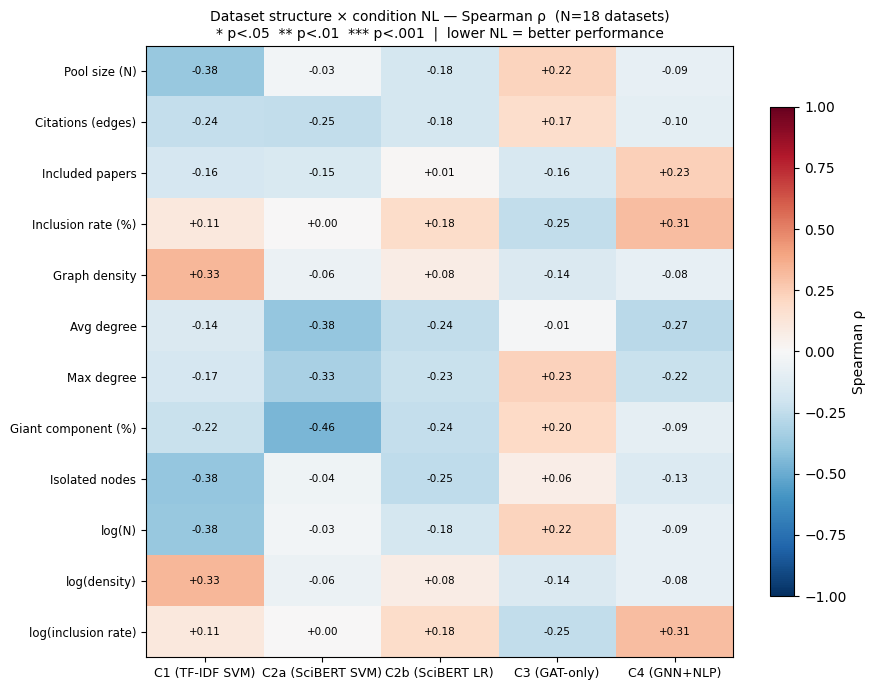

Saved figS1_structure_corr_heatmap.png


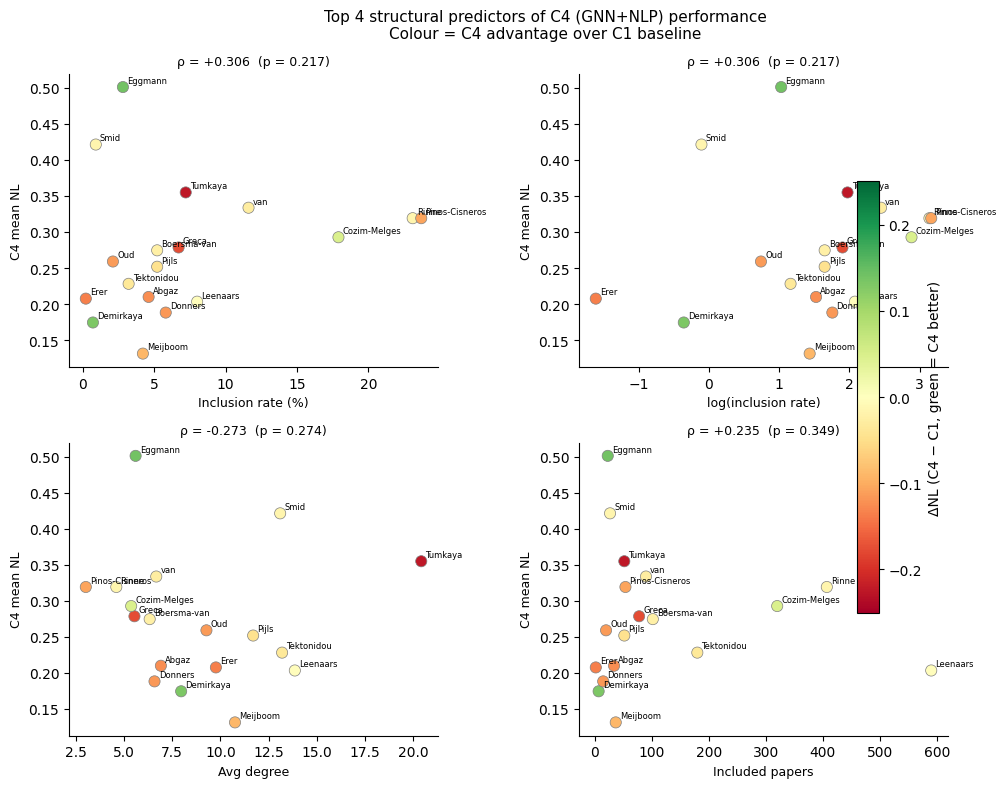

Saved figS2_top_structure_scatter.png


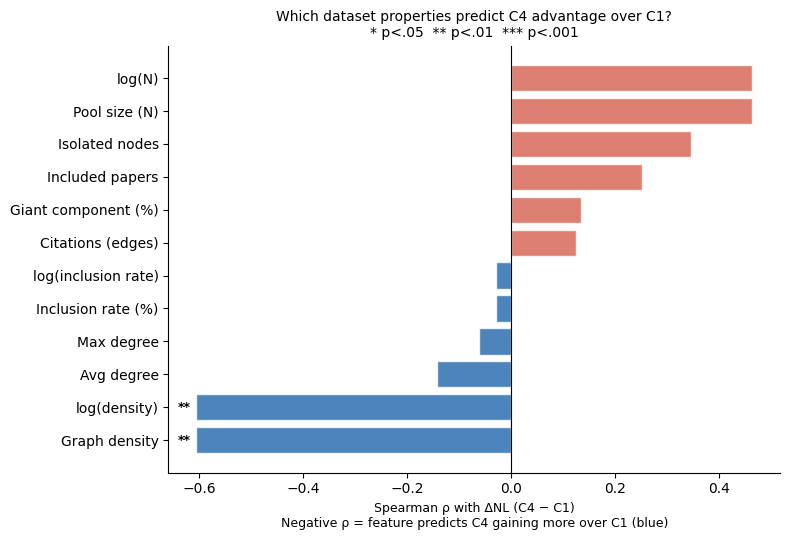

Saved figS3_delta_nl_correlates.png

=== Spearman ρ: structural features × C4 NL (sorted by |ρ|) ===
Feature                         ρ        p
Inclusion rate (%)         +0.306    0.217 
log(inclusion rate)        +0.306    0.217 
Avg degree                 -0.273    0.274 
Included papers            +0.235    0.349 
Max degree                 -0.221    0.378 
Isolated nodes             -0.134    0.595 
Citations (edges)          -0.100    0.693 
Giant component (%)        -0.089    0.724 
Pool size (N)              -0.086    0.735 
log(N)                     -0.086    0.735 
Graph density              -0.085    0.738 
log(density)               -0.085    0.738 

=== Spearman ρ: structural features × ΔNL(C4−C1) (sorted by |ρ|) ===
Feature                         ρ        p
Graph density              -0.606    0.008 **
log(density)               -0.606    0.008 **
Pool size (N)              +0.463    0.053 
log(N)                     +0.463    0.053 
Isolated nodes             +0.346  

In [30]:
# ─── Dataset Structure × Condition Performance — Correlation Study ───────────
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ── 1. Load structural features ────────────────────────────────────────────────
STRUCT_CSV = Path('../Week 2 - Dataset Selection/figures2/dataset_summary_stats.csv')
struct = pd.read_csv(STRUCT_CSV).set_index('dataset')

# ── 2. Build pool-aware per-dataset performance table ─────────────────────────
# Shared datasets (Pijls, Pinos-Cisneros, Tumkaya, Rinne) → use RQ1 performance
def primary_pool(ds):
    if ds in RQ1: return 'RQ1'
    if ds in RQ2_A: return 'RQ2_A_osteoarthritis'
    return 'RQ2_B_ptsd'

ALL_DS = list(dict.fromkeys(RQ1 + RQ2_A + RQ2_B))   # 18 unique, order-stable

perf_rows = []
for ds in ALL_DS:
    pn = primary_pool(ds)
    row = {'dataset': ds}
    for cond in CONDITION_ORDER:
        v = means[(means['pool']==pn) & (means['dataset']==ds) & (means['model']==cond)]['mean_nl']
        if len(v): row[cond] = float(v.iloc[0])
    perf_rows.append(row)

perf = pd.DataFrame(perf_rows).set_index('dataset')

# ── 3. Merge and add log features ─────────────────────────────────────────────
RAW_FEATS = ['n_nodes','n_edges','n_included','inclusion_rate',
             'density','avg_degree','max_degree','giant_frac','n_isolated']
merged = perf.join(struct[RAW_FEATS], how='inner').copy()
merged['log_n_nodes']        = np.log(merged['n_nodes'])
merged['log_density']        = np.log(merged['density'])
merged['log_inclusion_rate'] = np.log(merged['inclusion_rate'])
merged['delta_C4_C1']        = merged['C4_GNN_NLP_Fusion'] - merged['C1_TFIDF_SVM']

FEATS = RAW_FEATS + ['log_n_nodes', 'log_density', 'log_inclusion_rate']
FEAT_LABEL = {
    'n_nodes':            'Pool size (N)',
    'n_edges':            'Citations (edges)',
    'n_included':         'Included papers',
    'inclusion_rate':     'Inclusion rate (%)',
    'density':            'Graph density',
    'avg_degree':         'Avg degree',
    'max_degree':         'Max degree',
    'giant_frac':         'Giant component (%)',
    'n_isolated':         'Isolated nodes',
    'log_n_nodes':        'log(N)',
    'log_density':        'log(density)',
    'log_inclusion_rate': 'log(inclusion rate)',
}

print(f'Analysis dataset: {len(merged)} unique datasets')
print(merged[RAW_FEATS].describe().round(2).to_string())

# ── Figure S1 — Spearman ρ heatmap ────────────────────────────────────────────
rho_mat = np.zeros((len(FEATS), len(CONDITION_ORDER)))
p_mat   = np.zeros((len(FEATS), len(CONDITION_ORDER)))
for i, feat in enumerate(FEATS):
    for j, cond in enumerate(CONDITION_ORDER):
        valid = merged[[feat, cond]].dropna()
        rho, p = spearmanr(valid[feat], valid[cond])
        rho_mat[i, j] = rho; p_mat[i, j] = p

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(rho_mat, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(CONDITION_ORDER)))
ax.set_xticklabels([DISPLAY[c] for c in CONDITION_ORDER], fontsize=9)
ax.set_yticks(range(len(FEATS)))
ax.set_yticklabels([FEAT_LABEL[f] for f in FEATS], fontsize=8.5)
for i in range(len(FEATS)):
    for j in range(len(CONDITION_ORDER)):
        rho = rho_mat[i, j]; p = p_mat[i, j]
        stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        ax.text(j, i, f'{rho:+.2f}{stars}', ha='center', va='center', fontsize=7.5,
                color='white' if abs(rho) > 0.55 else 'black',
                fontweight='bold' if stars else 'normal')
plt.colorbar(im, ax=ax, label='Spearman ρ', shrink=0.8)
ax.set_title(
    f'Dataset structure × condition NL — Spearman ρ  (N={len(merged)} datasets)\n'
    '* p<.05  ** p<.01  *** p<.001  |  lower NL = better performance', fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'figS1_structure_corr_heatmap.png', dpi=200, bbox_inches='tight')
plt.show(); print('Saved figS1_structure_corr_heatmap.png')

# ── Figure S2 — Top C4 scatter panels ─────────────────────────────────────────
c4_corrs = []
for feat in FEATS:
    valid = merged[[feat, 'C4_GNN_NLP_Fusion', 'delta_C4_C1']].dropna()
    rho, p = spearmanr(valid[feat], valid['C4_GNN_NLP_Fusion'])
    c4_corrs.append((feat, rho, p, valid))
c4_corrs.sort(key=lambda x: abs(x[1]), reverse=True)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes_list = list(axes.flat)
sc = None
for ax, (feat, rho, p, valid) in zip(axes_list, c4_corrs[:4]):
    stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    sc = ax.scatter(valid[feat], valid['C4_GNN_NLP_Fusion'],
                    c=valid['delta_C4_C1'], cmap='RdYlGn', vmin=-0.25, vmax=0.25,
                    s=65, edgecolors='grey', linewidths=0.5, zorder=3)
    for ds in valid.index:
        ax.annotate(ds.split('_')[0],
                    (valid.loc[ds, feat], valid.loc[ds, 'C4_GNN_NLP_Fusion']),
                    fontsize=6, xytext=(3, 3), textcoords='offset points')
    ax.set_xlabel(FEAT_LABEL[feat], fontsize=9)
    ax.set_ylabel('C4 mean NL', fontsize=9)
    ax.set_title(f'ρ = {rho:+.3f}{stars}  (p = {p:.3f})', fontsize=9)
    ax.spines[['top','right']].set_visible(False)
plt.colorbar(sc, ax=axes_list, label='ΔNL (C4 − C1, green = C4 better)', shrink=0.7)
fig.suptitle('Top 4 structural predictors of C4 (GNN+NLP) performance\nColour = C4 advantage over C1 baseline', fontsize=11)
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.savefig(FIG_DIR / 'figS2_top_structure_scatter.png', dpi=200, bbox_inches='tight')
plt.show(); print('Saved figS2_top_structure_scatter.png')

# ── Figure S3 — ΔNL correlates: which features predict C4 gain over C1 ────────
delta_corrs = []
for feat in FEATS:
    valid = merged[[feat, 'delta_C4_C1']].dropna()
    rho, p = spearmanr(valid[feat], valid['delta_C4_C1'])
    delta_corrs.append((feat, rho, p))
delta_corrs.sort(key=lambda x: x[1])

fig, ax = plt.subplots(figsize=(8, 5.5))
colors = ['#2166ac' if rho < 0 else '#d6604d' for _, rho, _ in delta_corrs]
ax.barh([FEAT_LABEL[f] for f, _, _ in delta_corrs],
        [rho for _, rho, _ in delta_corrs],
        color=colors, alpha=0.8, edgecolor='white')
for i, (feat, rho, p) in enumerate(delta_corrs):
    stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    if stars:
        ax.text(rho + (0.01 if rho >= 0 else -0.01), i, stars,
                ha='left' if rho >= 0 else 'right', va='center',
                fontsize=9, fontweight='bold')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel(
    'Spearman ρ with ΔNL (C4 − C1)\n'
    'Negative ρ = feature predicts C4 gaining more over C1 (blue)', fontsize=9)
ax.set_title('Which dataset properties predict C4 advantage over C1?\n'
             '* p<.05  ** p<.01  *** p<.001', fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'figS3_delta_nl_correlates.png', dpi=200, bbox_inches='tight')
plt.show(); print('Saved figS3_delta_nl_correlates.png')

# ── Print tables ───────────────────────────────────────────────────────────────
print('\n=== Spearman ρ: structural features × C4 NL (sorted by |ρ|) ===')
print(f'{"Feature":<25} {"ρ":>7} {"p":>8}')
for feat, rho, p, _ in c4_corrs:
    stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f'{FEAT_LABEL[feat]:<25} {rho:>+7.3f} {p:>8.3f} {stars}')

print('\n=== Spearman ρ: structural features × ΔNL(C4−C1) (sorted by |ρ|) ===')
print(f'{"Feature":<25} {"ρ":>7} {"p":>8}')
for feat, rho, p in sorted(delta_corrs, key=lambda x: abs(x[1]), reverse=True):
    stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f'{FEAT_LABEL[feat]:<25} {rho:>+7.3f} {p:>8.3f} {stars}')


In [32]:
## 6. Claim verification: C4 NL vs C4 WSS@95 (ρ = −0.72 claim)
# The Discussion states: "When C4 achieved lower NL it also achieved higher WSS@95 (ρ = −0.72, p = 0.001)"
# This tests whether dataset-level C4 NL and C4 WSS@95 are negatively correlated across the 10 RQ1 datasets.

def mean_wss(pool, ds, m):
    v = [r['wss95'] for r in clean if r['pool'] == pool and r['dataset'] == ds and r['model'] == m]
    return sum(v) / len(v)

c4_nl  = [mean_nl ('RQ1', ds, 'C4_GNN_NLP_Fusion') for ds in RQ1]
c4_wss = [mean_wss('RQ1', ds, 'C4_GNN_NLP_Fusion') for ds in RQ1]

rho_nw, p_nw = spearmanr(c4_nl, c4_wss)
print("Claim: 'When C4 achieved lower NL it also achieved higher WSS@95 (ρ = −0.72, p = 0.001)'")
print(f"  Spearman ρ(C4 NL, C4 WSS@95) over {len(RQ1)} RQ1 datasets = {rho_nw:.3f}  p = {p_nw:.4f}")
print()

# Also compute across all 18 unique datasets for completeness
c4_nl_18  = [cval(d, 'C4_GNN_NLP_Fusion') for d in uniq]

def cval_wss(ds, m):
    pl = 'RQ1' if ds in RQ1 else 'RQ2_A_osteoarthritis' if ds in RQ2_A else 'RQ2_B_ptsd'
    return mean_wss(pl, ds, m)

c4_wss_18 = [cval_wss(d, 'C4_GNN_NLP_Fusion') for d in uniq]
rho_nw18, p_nw18 = spearmanr(c4_nl_18, c4_wss_18)
print(f"  Spearman ρ(C4 NL, C4 WSS@95) over {len(uniq)} unique datasets = {rho_nw18:.3f}  p = {p_nw18:.4f}")
print()
print("-> If ρ ≈ −0.72 and p ≈ 0.001: thesis claim confirmed.")
print("-> Note: negative ρ is expected (lower NL = better; higher WSS@95 = better → negatively correlated).")

NameError: name 'mean_nl' is not defined

In [ ]:
## 7. Claim verification: fusion benefit scales with C1 NL (ρ = 0.46 claim)
# The Discussion states: "the fusion benefit (C1 NL − C4 NL) tends to increase with C1 NL
# (ρ = 0.46, p = 0.06, a weak trend)"
# Tested over 18 unique datasets.

c1_nl_18   = [cval(d, 'C1_TFIDF_SVM')       for d in uniq]
c4_nl_18   = [cval(d, 'C4_GNN_NLP_Fusion')  for d in uniq]
benefit_18 = [c1 - c4 for c1, c4 in zip(c1_nl_18, c4_nl_18)]   # positive = C4 improves on C1

rho_fb, p_fb = spearmanr(c1_nl_18, benefit_18)
print("Claim: 'fusion benefit (C1 NL − C4 NL) tends to increase with C1 NL (ρ = 0.46, p = 0.06)'")
print(f"  Spearman ρ(C1 NL, C1−C4 benefit) over {len(uniq)} unique datasets = {rho_fb:.3f}  p = {p_fb:.4f}")
print()

# Breakdown: which datasets show large C1 NL and large fusion benefit?
print(f"  {'dataset':<22} {'C1 NL':>7} {'C4 NL':>7} {'benefit':>9}")
for d, c1, c4, b in sorted(zip(uniq, c1_nl_18, c4_nl_18, benefit_18), key=lambda x: -x[1]):
    print(f"  {d:<22} {c1:>7.3f} {c4:>7.3f} {b:>+9.3f}")